In [3]:
import pandas as pd

In [4]:
df=pd.read_excel("C:/Users/ramya/Downloads/Sales data.xlsx")

In [6]:
df.isnull()

,Unnamed: 0,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [13]:
df.drop_duplicates(inplace=True)

In [15]:
print(df)

       order_id  order_date  product_id product_category   price  \
0             1  2022-04-13        2637            Books  128.75   
1             2  2023-03-12        2300          Fashion  302.60   
2             3  2022-09-28        3670           Sports  495.80   
3             4  2022-04-17        2522            Books  371.95   
4             5  2022-03-13        1717           Beauty  201.68   
...         ...         ...         ...              ...     ...   
49995     49996  2022-09-03        1433           Beauty   26.99   
49996     49997  2022-07-03        1428           Beauty  294.23   
49997     49998  2023-02-17        4651      Electronics  352.11   
49998     49999  2022-09-30        4371           Beauty  307.54   
49999     50000  2023-06-29        2944   Home & Kitchen  253.44   

       discount_percent  quantity_sold customer_region payment_method  rating  \
0                    10              4   North America            UPI     3.5   
1                    

In [17]:
# algorithm 4
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) |
              (df['price'] > upper)]

print(outliers)

Empty DataFrame
Columns: [order_id, order_date, product_id, product_category, price, discount_percent, quantity_sold, customer_region, payment_method, rating, review_count, discounted_price, total_revenue]
Index: []


In [20]:
Q1 = df['total_revenue'].quantile(0.25)
Q3 = df['total_revenue'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_revenue'] < lower) |
              (df['total_revenue'] > upper)]

print(outliers)

       order_id  order_date  product_id product_category   price  \
204         205  2023-01-21        1256   Home & Kitchen  469.04   
216         217  2022-08-13        2764      Electronics  483.28   
291         292  2022-04-14        1917            Books  489.42   
300         301  2023-12-07        2959            Books  490.29   
466         467  2022-03-10        2000   Home & Kitchen  443.64   
...         ...         ...         ...              ...     ...   
49738     49739  2022-06-28        1947           Sports  489.35   
49827     49828  2022-08-13        4527          Fashion  415.28   
49894     49895  2023-11-27        3024   Home & Kitchen  476.78   
49922     49923  2023-12-02        3363          Fashion  444.14   
49969     49970  2023-09-10        4993      Electronics  414.64   

       discount_percent  quantity_sold customer_region    payment_method  \
204                   5              5   North America               UPI   
216                   0        

In [22]:
print("Number of outliers:", len(outliers))

Number of outliers: 752


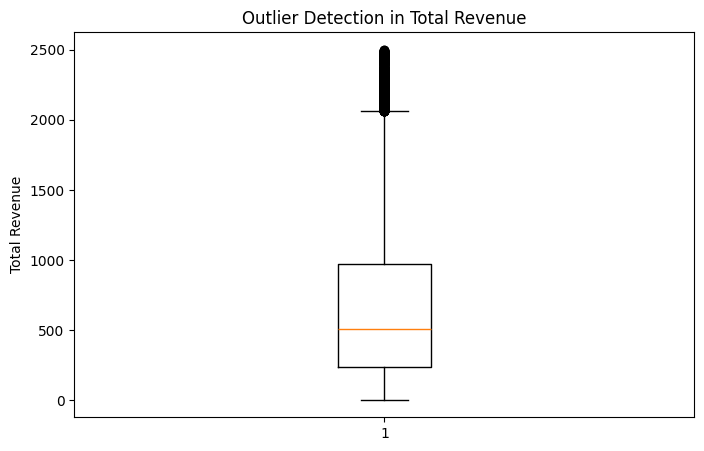

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["total_revenue"])
plt.title("Outlier Detection in Total Revenue")
plt.ylabel("Total Revenue")
plt.show()

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['total_revenue']] = scaler.fit_transform(df[['total_revenue']])
print(df[['total_revenue']])

   total_revenue
0       0.184188
1       0.483454
2       0.316319
3       0.505187
4       0.321704
       total_revenue
0           0.184188
1           0.483454
2           0.316319
3           0.505187
4           0.321704
...              ...
49995       0.052534
49996       0.528992
49997       0.393507
49998       0.115526
49999       0.069547

[50000 rows x 1 columns]


In [32]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Read original dataset
df = pd.read_csv("C:/Users/ramya/Downloads/archive (4).zip", compression="zip")

encoder = LabelEncoder()

df["product_category"] = encoder.fit_transform(df["product_category"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'Beauty': np.int64(0), 'Books': np.int64(1), 'Electronics': np.int64(2), 'Fashion': np.int64(3), 'Home & Kitchen': np.int64(4), 'Sports': np.int64(5)}


In [34]:
import pandas as pd

df = pd.read_csv("C:/Users/ramya/Downloads/archive (4).zip", compression="zip")

one_hot = pd.get_dummies(df["product_category"])

print(one_hot.head())

   Beauty  Books  Electronics  Fashion  Home & Kitchen  Sports
0   False   True        False    False           False   False
1   False  False        False     True           False   False
2   False  False        False    False           False    True
3   False   True        False    False           False   False
4    True  False        False    False           False   False


In [35]:
one_hot = pd.get_dummies(df["product_category"], dtype=int)
print(one_hot.head())

   Beauty  Books  Electronics  Fashion  Home & Kitchen  Sports
0       0      1            0        0               0       0
1       0      0            0        1               0       0
2       0      0            0        0               0       1
3       0      1            0        0               0       0
4       1      0            0        0               0       0
